8.Data Visualization I

1.Use the inbuilt dataset 'titanic'. The dataset contains 891 rows and contains information
about the passengers who boarded the unfortunate Titanic ship. Use the Seaborn library to
see if we can find any patterns in the data.

2.Write a code to check how the price of the ticket (column name: 'fare') for each passenger
is distributed by plotting a histogram.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for better visualizations
sns.set(style="whitegrid")
plt.style.use('seaborn-v0_8')

In [18]:
# Load the Titanic dataset
titanic_df = sns.load_dataset('titanic')

# Display the first few rows of the dataset
print("First 5 rows of the Titanic dataset:")
display(titanic_df.head())

# Display basic information about the dataset
print("\nBasic information about the dataset:")
print(f"Number of rows: {titanic_df.shape[0]}")
print(f"Number of columns: {titanic_df.shape[1]}")
print("\nColumn names and data types:")
display(titanic_df.info())

First 5 rows of the Titanic dataset:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



Basic information about the dataset:
Number of rows: 891
Number of columns: 15

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), ob

None

In [4]:
# Display summary statistics
print("\nSummary statistics:")
display(titanic_df.describe())

# Check missing values
print("\nMissing values in each column:")
missing_values = titanic_df.isnull().sum().sort_values(ascending=False)
missing_percent = (titanic_df.isnull().sum() / titanic_df.shape[0] * 100).sort_values(ascending=False)
missing_data = pd.concat([missing_values, missing_percent], axis=1, keys=['Total', 'Percent'])
display(missing_data)


Summary statistics:


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



Missing values in each column:


,Total,Percent
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


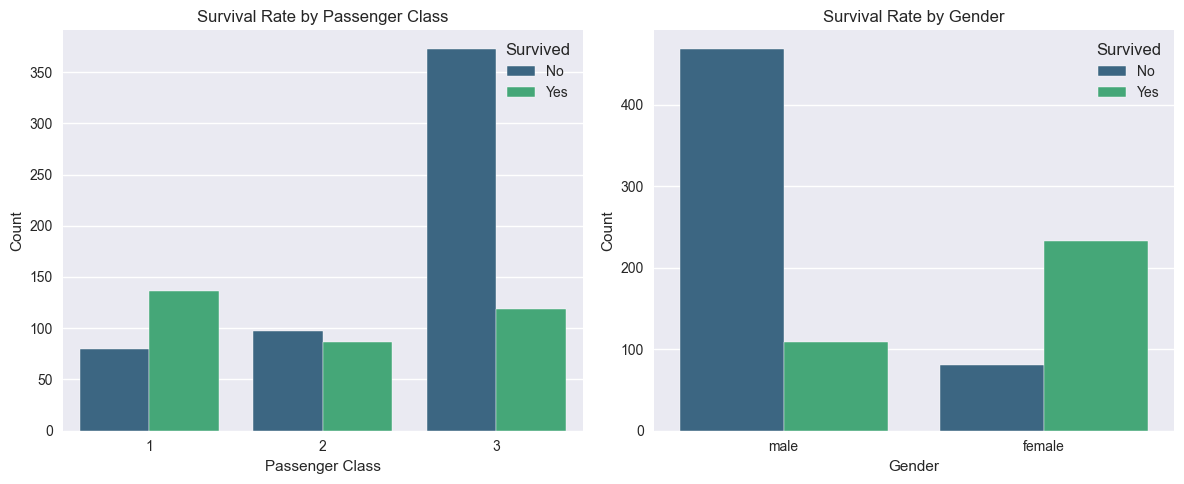

In [5]:
# Visualization 1: Survival rate by passenger class and gender
plt.figure(figsize=(12, 5))

# Survival rate by passenger class
plt.subplot(1, 2, 1)
sns.countplot(x='pclass', hue='survived', data=titanic_df, palette='viridis')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])

# Survival rate by gender
plt.subplot(1, 2, 2)
sns.countplot(x='sex', hue='survived', data=titanic_df, palette='viridis')
plt.title('Survival Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])

plt.tight_layout()
plt.show()

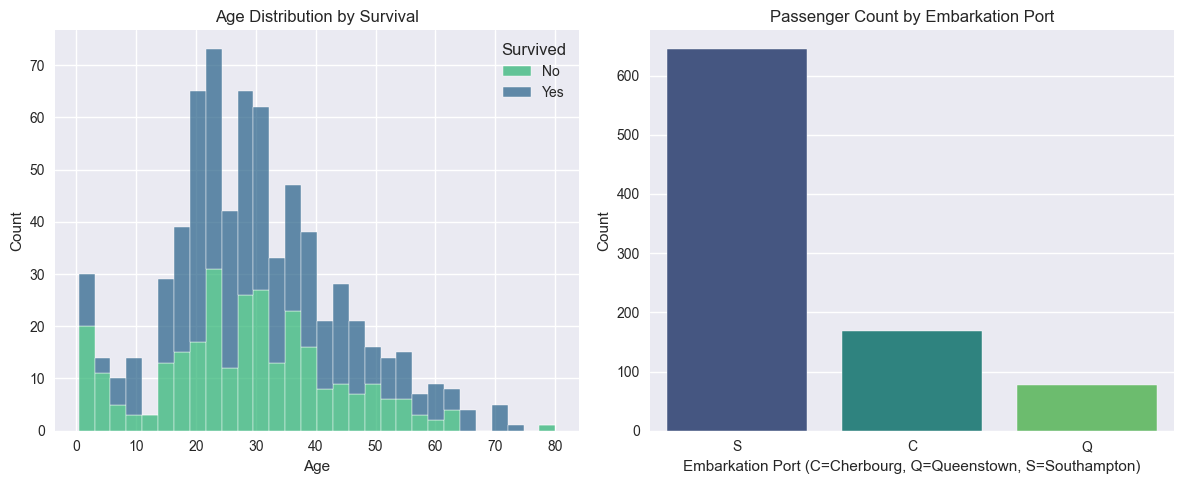

In [6]:
# Visualization 2: Age distribution and embarkation port analysis
plt.figure(figsize=(12, 5))

# Age distribution with survival
plt.subplot(1, 2, 1)
sns.histplot(data=titanic_df, x='age', hue='survived', multiple='stack', bins=30, palette='viridis')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])

# Distribution of passengers by embarkation port
plt.subplot(1, 2, 2)
# Use hue with same variable and set legend=False to avoid duplicate legend
sns.countplot(x='embarked', hue='embarked', data=titanic_df, palette='viridis', legend=False)
plt.title('Passenger Count by Embarkation Port')
plt.xlabel('Embarkation Port (C=Cherbourg, Q=Queenstown, S=Southampton)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

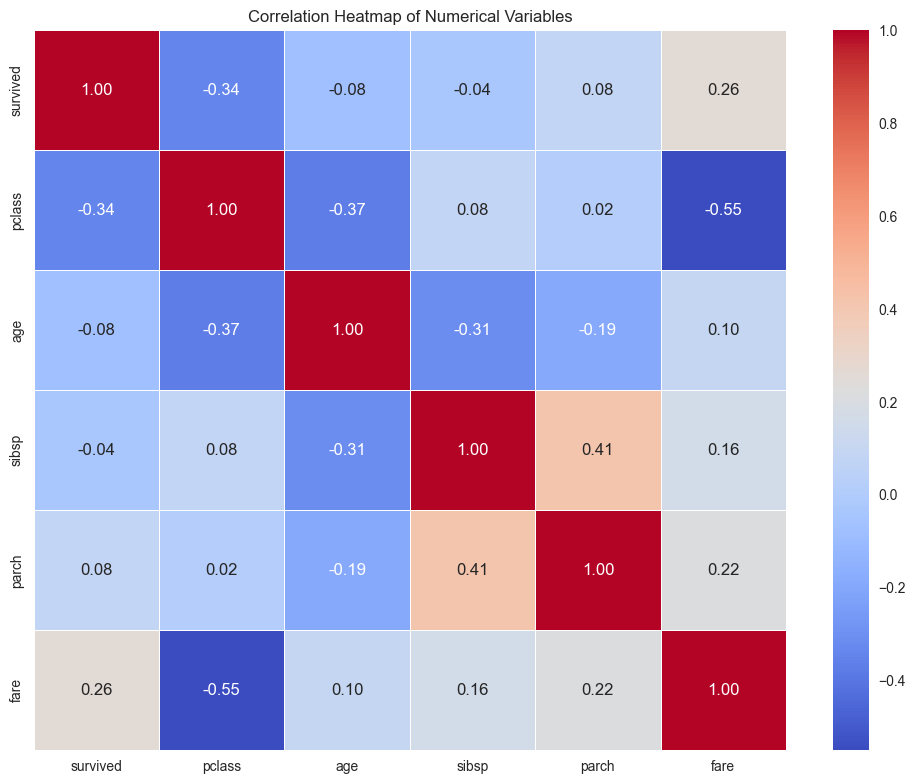

In [7]:
# Visualization 3: Correlation heatmap of numerical variables
plt.figure(figsize=(10, 8))

# Select only numeric columns
numeric_df = titanic_df.select_dtypes(include=[np.number])

# Calculate correlation matrix
corr_matrix = numeric_df.corr()

# Create heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

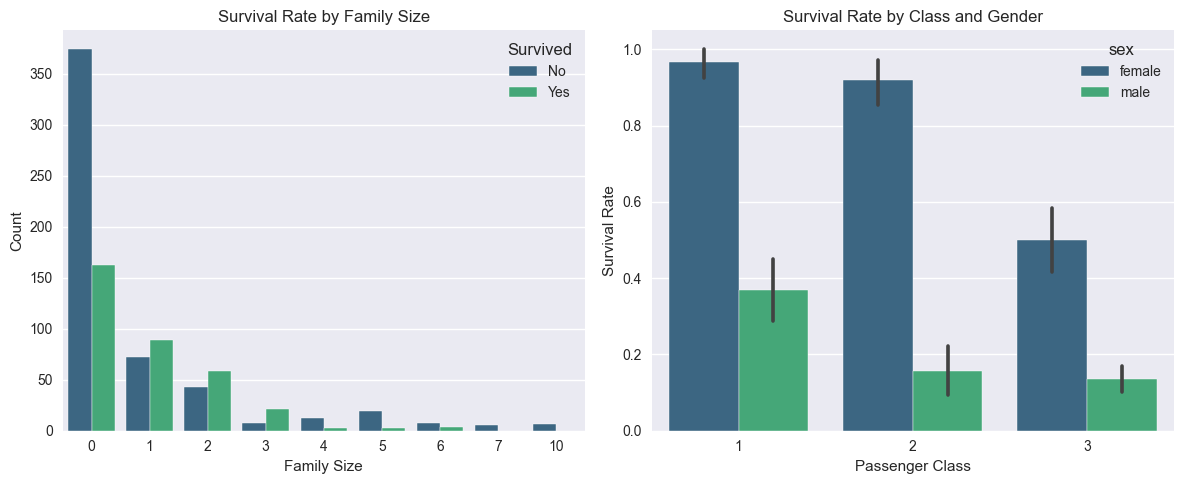

In [8]:
# Visualization 4: Family size and survival rate by class and gender
# Create family size feature
titanic_df['family_size'] = titanic_df['sibsp'] + titanic_df['parch']

plt.figure(figsize=(12, 5))

# Survival rate by family size
plt.subplot(1, 2, 1)
sns.countplot(x='family_size', hue='survived', data=titanic_df, palette='viridis')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])

# Survival rate by passenger class and gender
plt.subplot(1, 2, 2)
sns.barplot(x='pclass', y='survived', hue='sex', data=titanic_df, palette='viridis')
plt.title('Survival Rate by Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')

plt.tight_layout()
plt.show()

C:\Users\abhis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


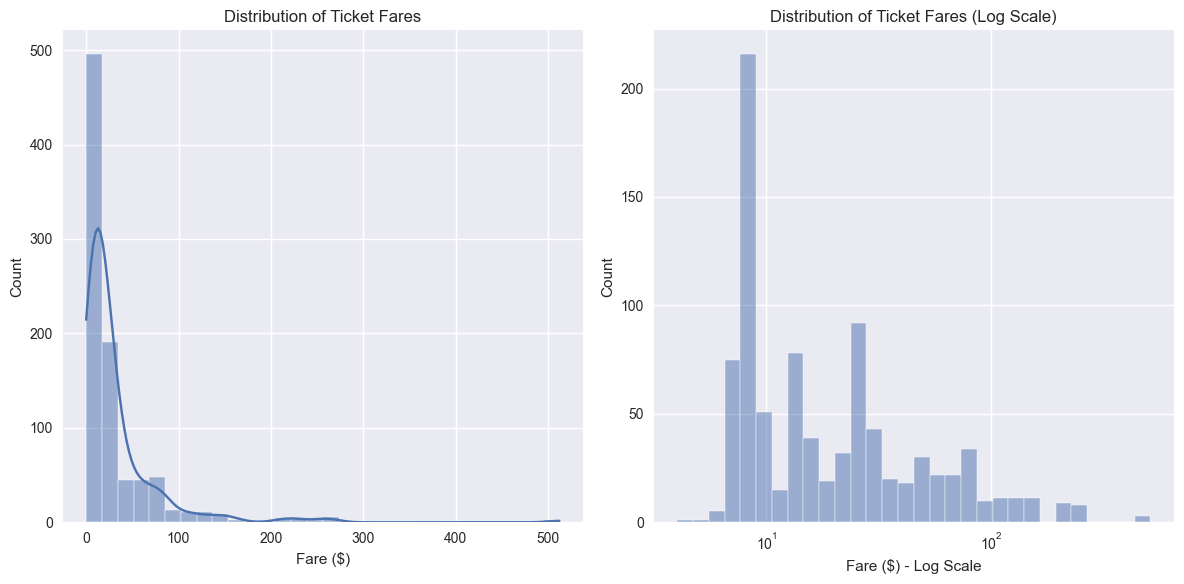

In [9]:
# Visualization 5: Ticket fare distribution - normal and log scale
plt.figure(figsize=(12, 6))

# Simple histogram of fare
plt.subplot(1, 2, 1)
sns.histplot(data=titanic_df, x='fare', bins=30, kde=True)
plt.title('Distribution of Ticket Fares')
plt.xlabel('Fare ($)')
plt.ylabel('Count')

# Logarithmic scale for better visualization of skewed data
plt.subplot(1, 2, 2)
sns.histplot(data=titanic_df, x='fare', bins=30, log_scale=True, kde=True)
plt.title('Distribution of Ticket Fares (Log Scale)')
plt.xlabel('Fare ($) - Log Scale')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

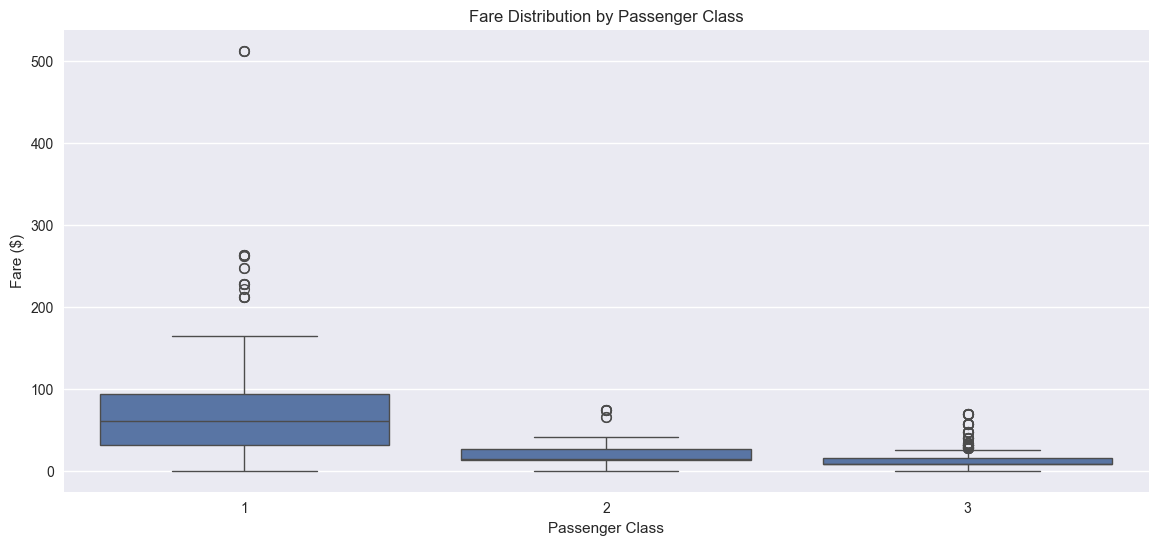

In [10]:
# Visualization 6: Fare distribution by passenger class
plt.figure(figsize=(14, 6))
sns.boxplot(x='pclass', y='fare', data=titanic_df)
plt.title('Fare Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Fare ($)')
plt.show()

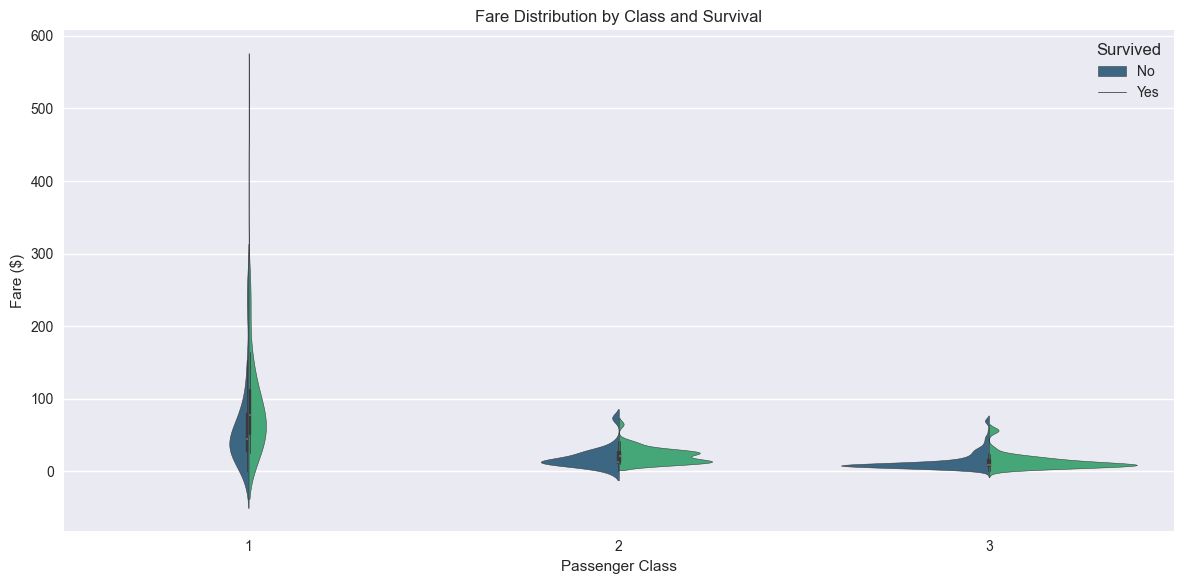

In [11]:
# Visualization 7: Fare distribution by passenger class and survival
plt.figure(figsize=(12, 6))
sns.violinplot(x='pclass', y='fare', hue='survived', data=titanic_df, split=True, palette='viridis')
plt.title('Fare Distribution by Class and Survival')
plt.xlabel('Passenger Class')
plt.ylabel('Fare ($)')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

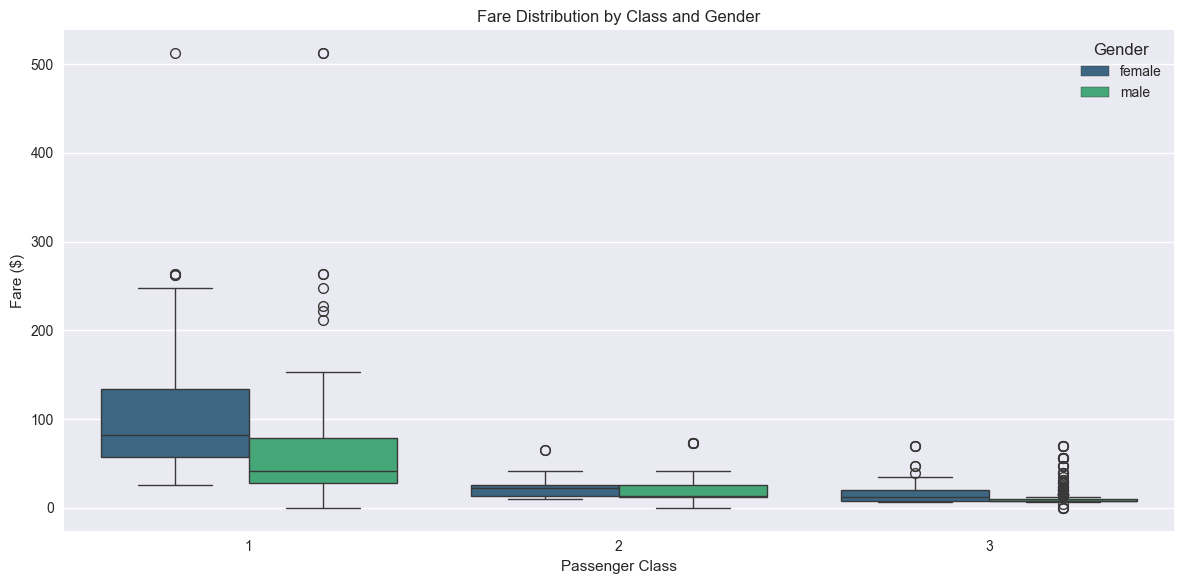

In [13]:
# Visualization 8: Fare distribution by class and gender
plt.figure(figsize=(12, 6))
sns.boxplot(x='pclass', y='fare', hue='sex', data=titanic_df, palette='viridis')
plt.title('Fare Distribution by Class and Gender')
plt.xlabel('Passenger Class')
plt.ylabel('Fare ($)')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

<Figure size 1600x1200 with 0 Axes>

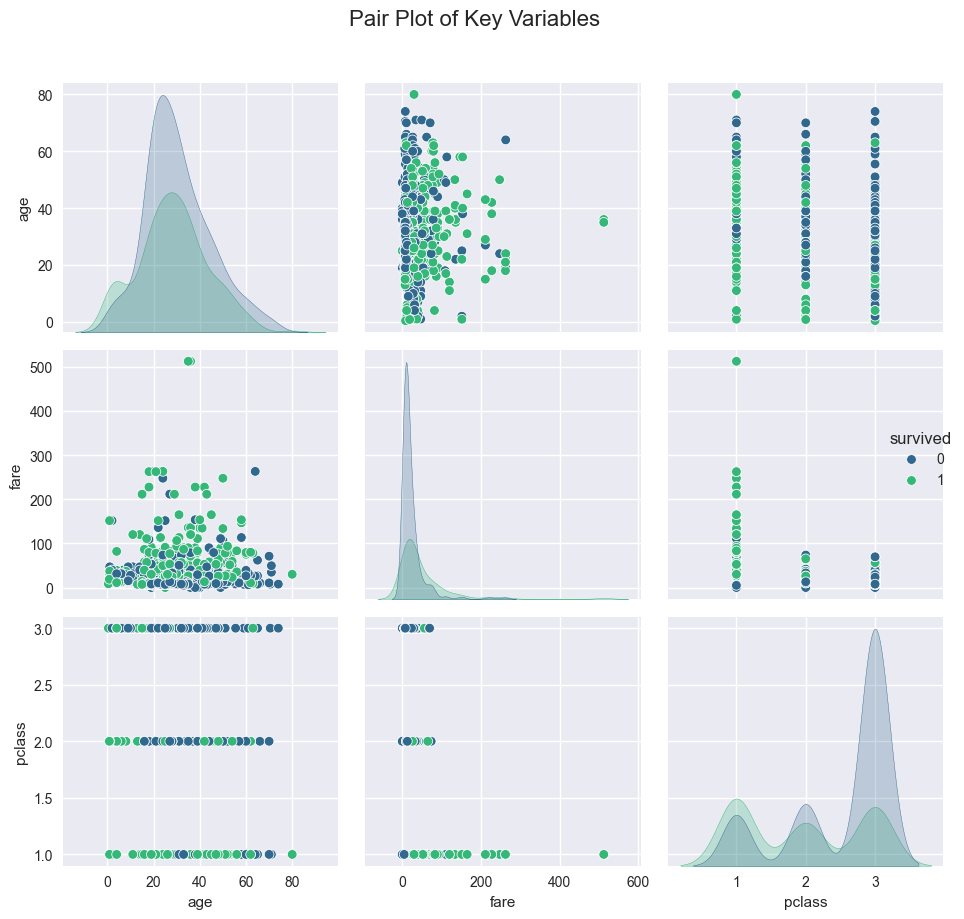

In [14]:
# Visualization 9: Pair plot of key variables
plt.figure(figsize=(16, 12))
sns.pairplot(data=titanic_df, vars=['age', 'fare', 'pclass'], hue='survived', palette='viridis', 
             diag_kind='kde', height=3, aspect=1)
plt.suptitle('Pair Plot of Key Variables', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

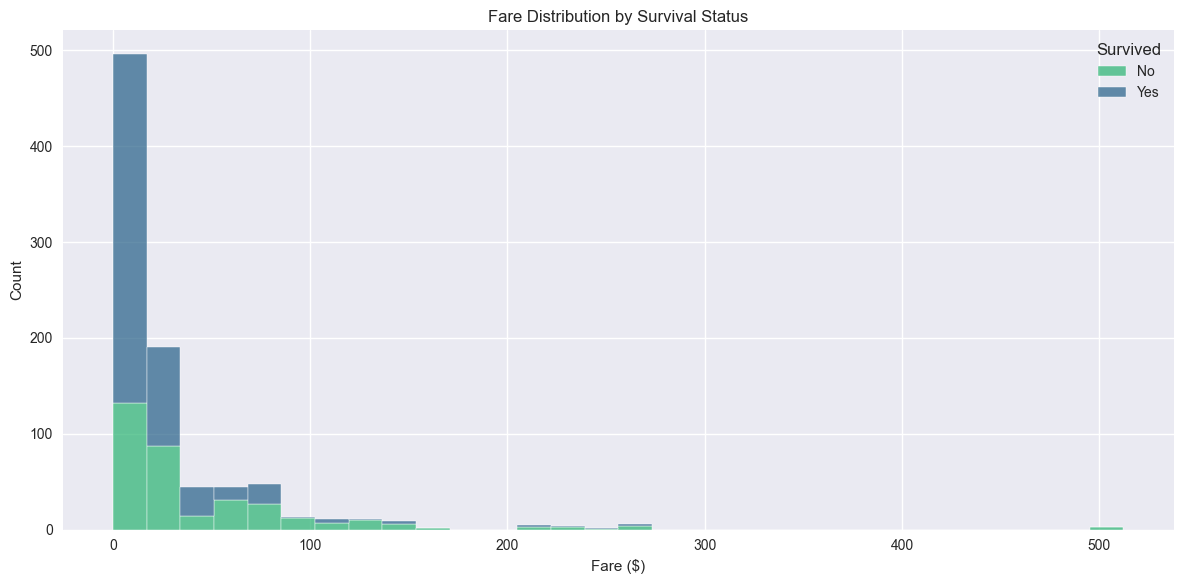

In [15]:
# Visualization 10: Fare distribution by survival status
plt.figure(figsize=(12, 6))
sns.histplot(data=titanic_df, x='fare', hue='survived', multiple='stack', bins=30, palette='viridis')
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Fare ($)')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

In [16]:
# Summary of key findings
print("\nKey Findings from the Titanic Dataset Analysis:")
print("1. Higher class passengers (1st class) had higher survival rates")
print("2. Females had significantly higher survival rates than males")
print("3. Children (especially young ones) had higher survival rates")
print("4. Passengers who paid higher fares had better survival chances")
print("5. Passengers traveling alone had lower survival rates than those with family")
print("6. Most passengers embarked from Southampton (S)")


Key Findings from the Titanic Dataset Analysis:
1. Higher class passengers (1st class) had higher survival rates
2. Females had significantly higher survival rates than males
3. Children (especially young ones) had higher survival rates
4. Passengers who paid higher fares had better survival chances
5. Passengers traveling alone had lower survival rates than those with family
6. Most passengers embarked from Southampton (S)
